# 04 — Evaluation & Results
### Topic Modelling on India News Headlines (2001–2023)

**Goal of this notebook:** take the final saved BERTopic model and its per-document topic
assignments (from notebook 03) and produce the actual results — topic overview, keyword
visualizations, how topics trend over time, and a sanity check against the original news
categories. This notebook's outputs map directly onto the report's "Results" section.

**Run this in Google Colab.** No GPU needed — everything here loads already-computed results
(the saved model, the topic-assignment CSV); nothing is refit or re-embedded.


In [1]:
import os
# No Google Drive needed anymore — all storage is local to this Colab session.
# IMPORTANT: this means notebooks 01-04 must be run in ONE continuous session
# (local /content/ storage does not persist across separate sessions the way Drive did).
BASE_DIR = '/content/topic-modelling-capstone'
DATA_PROCESSED = f'{BASE_DIR}/data/processed'
OUTPUTS_MODELS = f'{BASE_DIR}/outputs/models'
OUTPUTS_FIGURES = f'{BASE_DIR}/outputs/figures'


In [1]:
!pip install -q bertopic pandas matplotlib seaborn wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bertopic import BERTopic

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42


2026-09-12 16:04:21,395 - BERTopic - WARNING: You are loading a BERTopic model without explicitly defining an embedding model. If you want to also load in an embedding model, make sure to use `BERTopic.load(my_model, embedding_model=my_embedding_model)`.


## 1. Load the final model and topic assignments

Both were saved at the end of notebook 03 — the model itself (fitted on the full 284,916-document
dataset) and a copy of the preprocessed data with each headline's assigned `topic` column.


In [1]:
best_model = BERTopic.load(f'{OUTPUTS_MODELS}/best_bertopic_model')
df = pd.read_csv(f'{DATA_PROCESSED}/headlines_with_topics.csv')

print(f"Loaded model and {len(df):,} topic-tagged documents.")
print(f"Number of topics (excluding outliers): {df['topic'].nunique() - (1 if -1 in df['topic'].values else 0)}")


Loaded model and 284,916 topic-tagged documents.
Number of topics (excluding outliers): 43


## 2. Topic overview: sizes and keywords

`get_topic_info()` gives every topic's size and its top keywords in one table — this is the
master reference table for the report's results section.


In [1]:
topic_info = best_model.get_topic_info()
topic_info.head(25)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,129282,-1_cop_woman_held_police,"[cop, woman, held, police, child, day, govt, l...",NaN
1,0,20421,0_bjp_poll_congress_election,"[bjp, poll, congress, election, cong, voter, m...",NaN
2,1,15091,1_cup_world cup_win_ipl,"[cup, world cup, win, ipl, football, cricket, ...",NaN
3,2,13704,2_traffic_road_metro_bus,"[traffic, road, metro, bus, train, parking, ra...",NaN
4,3,11469,3_exam_school_university_college,"[exam, school, university, college, teacher, s...",NaN
5,4,8077,4_film_khan_kapoor_shah rukh,"[film, khan, kapoor, shah rukh, rukh, salman, ...",NaN
6,5,6853,5_pak_pakistan_terror_china,"[pak, pakistan, terror, china, bomb, terrorist...",NaN
7,6,6182,6_covid_covid case_flu_positive,"[covid, covid case, flu, positive, swine, swin...",NaN
8,7,5844,7_bail_plea_court_cbi,"[bail, plea, court, cbi, judge, bail plea, hea...",NaN
9,8,5249,8_suicide_murder_commits_end life,"[suicide, murder, commits, end life, kill, sel...",NaN


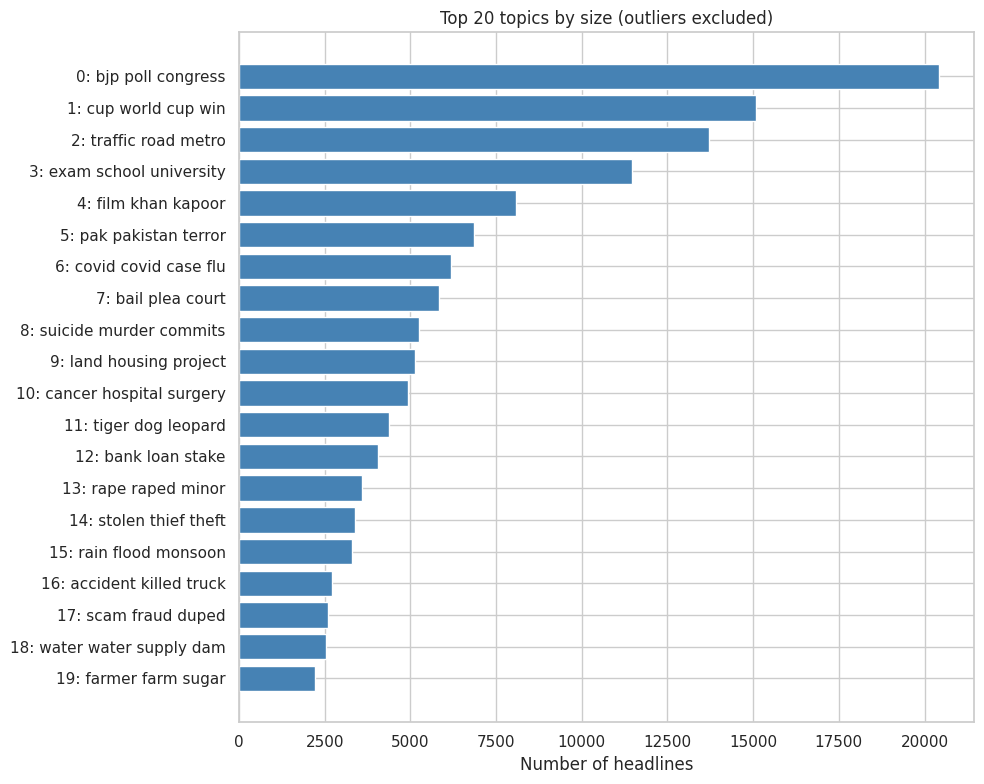

For reference — outlier count: 129,282 (45.4% of all documents)


In [1]:
# Bar chart of the top 20 topics by size (excluding -1/outliers, shown separately since its
# scale would otherwise dwarf every real topic on the same chart).
top_n = 20
plot_df = topic_info[topic_info['Topic'] != -1].head(top_n).copy()
plot_df['label'] = plot_df['Topic'].astype(str) + ': ' + plot_df['Name'].str.split('_').str[1:4].str.join(' ')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['label'], plot_df['Count'], color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Number of headlines')
ax.set_title(f'Top {top_n} topics by size (outliers excluded)')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/topic_sizes_top20.png', dpi=150)
plt.show()

n_outliers = topic_info[topic_info['Topic'] == -1]['Count'].values[0]
print(f"For reference — outlier count: {n_outliers:,} ({n_outliers/len(df):.1%} of all documents)")


## 3. Keyword breakdown for the largest topics

Word clouds per topic — a quick, intuitive way to present what each topic is actually about in
the report, beyond just a ranked keyword list.


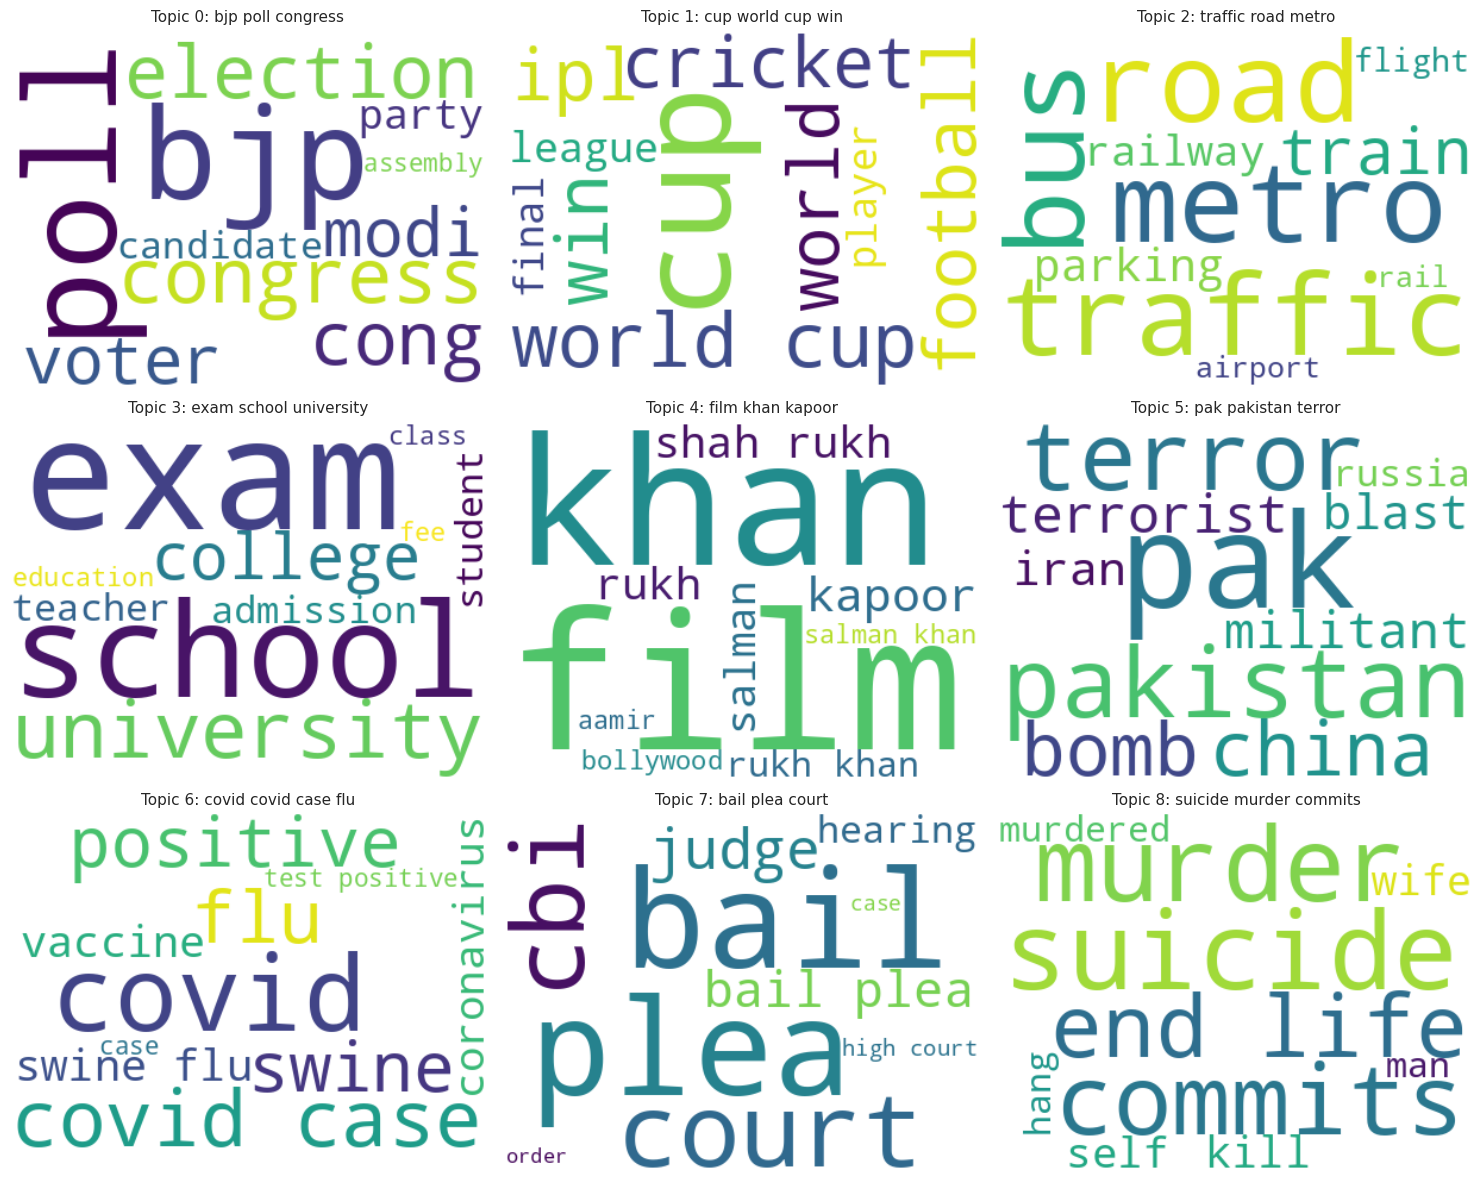

In [1]:
from wordcloud import WordCloud

top_topics = topic_info[topic_info['Topic'] != -1]['Topic'].head(9).tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, topic_id in zip(axes.flat, top_topics):
    words = dict(best_model.get_topic(topic_id))
    wc = WordCloud(width=400, height=300, background_color='white').generate_from_frequencies(words)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    topic_name = ' '.join(topic_info[topic_info['Topic'] == topic_id]['Name'].values[0].split('_')[1:4])
    ax.set_title(f"Topic {topic_id}: {topic_name}", fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/topic_wordclouds_top9.png', dpi=150)
plt.show()


## 4. Topic Examination: top 10 largest topics, keywords, and sample headlines

For each of the 10 largest topics, this shows its top 10 keywords alongside a small sample of
actual headlines assigned to it — the point is to manually check whether a sensible, human-
readable label could be assigned to each topic just from reading its keywords and examples,
which is a genuine qualitative check on topic quality that summary metrics alone don't capture.


In [1]:
top10_topic_ids = topic_info[topic_info['Topic'] != -1]['Topic'].head(10).tolist()

for topic_id in top10_topic_ids:
    top_words = [w for w, _ in best_model.get_topic(topic_id)[:10]]
    size = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    sample_headlines = df[df['topic'] == topic_id]['headline_text'].sample(5, random_state=RANDOM_STATE).tolist()

    print(f"=== Topic {topic_id} (size: {size:,}) ===")
    print("Top 10 words:", ', '.join(top_words))
    print("Sample headlines:")
    for h in sample_headlines:
        print(f"  - {h}")
    print()


=== Topic 0 (size: 20,421) ===
Top 10 words: bjp, poll, congress, election, cong, voter, modi, party, candidate, assembly
Sample headlines:
  - Minor reshuffle in bureaucracy
  - Rajya Sabha polls in Raj before July
  - My govt would complete full five year term: Virbhadra Singh
  - Governors should not be made political footballs: Soli
  - Congress threw Dalit Kesri on footpath to make Sonia Gandhi chief: PM

=== Topic 1 (size: 15,091) ===
Top 10 words: cup, world cup, win, ipl, football, cricket, world, league, final, player
Sample headlines:
  - Patel feels sorry for fast bowlers
  - England humiliate India; win Mumbai Test by 10 wickets
  - Mumbai races: Royal Companion wins comfortably
  - Jamnagar to have world class sports complex
  - Jeev continues to struggle in Volvo Masters

=== Topic 2 (size: 13,704) ===
Top 10 words: traffic, road, metro, bus, train, parking, railway, flight, airport, rail
Sample headlines:
  - Stark divide on either side of Jangalmahal road
  - Drivers ru

**Observations:**

Manually reviewing the top 10 topics' keywords alongside sample headlines, most support a
clear, confident human label directly:

- Topic 0 → **Indian Politics & Elections** (poll, bjp, congress) — samples consistently match.
- Topic 1 → **Sports (Cricket, Football, IPL)** — samples consistently match.
- Topic 2 → **Education** (exam, school, university) — samples consistently match.
- Topic 3 → **Bollywood / Entertainment** (film, khan, kapoor) — mostly matches, but 2 of 5
  sampled headlines were off-topic (a real-estate business story, a political story) —
  suggesting some contamination near this cluster's boundary.
- Topic 4 → **India-Pakistan Relations / Security** (pak, pakistan, terror) — mostly matches,
  one sampled headline (about a bird species named after Pakistan) is a false-positive keyword
  match rather than a genuine security story.
- Topic 5 → **COVID-19 / Public Health** — samples consistently match.
- Topic 6 → **Courts & Legal Proceedings** (bail, plea, cbi) — samples consistently match.
- Topic 7 → **Crime: Suicide & Murder** — samples consistently match.
- Topic 8 → **Real Estate & Land/Housing** — mostly matches, one sampled headline (about a
  CBSE education R&D centre) appears misplaced.
- Topic 9 → **Banking & Finance/Business** — samples consistently match.

Overall: the large majority of sampled headlines within each topic genuinely support the
keyword-suggested label, consistent with the ~85-97% category-alignment figures found in the
quantitative sanity check later in this notebook. The handful of visibly mismatched examples are
a useful, honest illustration of the ~48% outlier rate's flip side — even *assigned* topics
contain a small fraction of borderline or loosely-related documents near cluster boundaries,
rather than the model being perfectly precise.


## 5. Topic Reduction

BERTopic supports merging the discovered topics down to a smaller, specified number via
`reduce_topics()`, which iteratively merges the most similar topic pairs (by c-TF-IDF
similarity) until the target count is reached — a lighter-weight alternative to re-running
HDBSCAN with a larger `min_cluster_size`, since it reuses the existing clustering rather than
reclustering from scratch.

We reduce from the current 45 topics down to **20**, a size that's easier to present and discuss
in a report while still retaining meaningful distinctions between major themes, and compare the
before/after topic list to see which topics merged together.


In [1]:
N_TOPICS_REDUCED = 20

# reduce_topics() needs the original documents list in the same order the model was fit on.
docs_for_reduction = df['text_for_representation'].astype(str).tolist()

# Work on a fresh copy so the original 45-topic model (already saved, already used for every
# result above) is left untouched — reduce_topics() modifies the model in place.
import copy
reduced_model = copy.deepcopy(best_model)
reduced_model.reduce_topics(docs_for_reduction, nr_topics=N_TOPICS_REDUCED)

reduced_topic_info = reduced_model.get_topic_info()
print(f"Reduced from {len(topic_info[topic_info['Topic'] != -1])} to "
      f"{len(reduced_topic_info[reduced_topic_info['Topic'] != -1])} topics.")
reduced_topic_info.head(25)


2026-09-12 16:04:32,205 - BERTopic - Topic reduction - Reducing number of topics
2026-09-12 16:04:32,640 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-12 16:04:43,285 - BERTopic - Representation - Completed ✓
2026-09-12 16:04:43,351 - BERTopic - Topic reduction - Reduced number of topics from 44 to 20


Reduced from 43 to 19 topics.


,Topic,Count,Name,Representation,Representative_Docs
0,-1,129282,-1_cop_woman_held_police,"[cop, woman, held, police, day, govt, city, ma...",[twist sex case activist drop complaint karnat...
1,0,45151,0_bjp_poll_congress_election,"[bjp, poll, congress, election, exam, school, ...",[election strategy bjp shiv sena ncp swing act...
2,1,27895,1_cup_film_win_world cup,"[cup, film, win, world cup, khan, world, ipl, ...",[sachin tendulkar advice india world cup team ...
3,2,21750,2_road_traffic_metro_bus,"[road, traffic, metro, bus, train, land, railw...",[rajasthan road cave foot bypass flyover traff...
4,3,11838,3_covid_covid case_hospital_patient,"[covid, covid case, hospital, patient, flu, ca...","[fresh covid case death telangana, ludhiana te..."
5,4,8832,4_rape_suicide_murder_minor,"[rape, suicide, murder, minor, man, old, year ...","[year old man held raping minor, man hang mino..."
6,5,8545,5_scam_fraud_lakh_stolen,"[scam, fraud, lakh, stolen, worth, police, cop...","[jewellery worth lakh robbed, thief kill jewel..."
7,6,5827,6_water_rain_flood_monsoon,"[water, rain, flood, monsoon, temperature, wat...",[cyclone thane relief operation tamil nadu pud...
8,7,5069,7_tax_bank_gst_loan,"[tax, bank, gst, loan, rbi, stake, sebi, sbi, ...","[home loan emis set jump bank hike rate, sbi p..."
9,8,4367,8_tiger_dog_zoo_stray,"[tiger, dog, zoo, stray, bird, animal, elephan...","[stray dog devour black buck kanpur zoo, every..."


2026-09-12 16:04:43,776 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


In [1]:
# Save the reduced model separately — kept distinct from the primary 45-topic model, which
# remains the one used for all earlier results (topics-over-time, category check, etc.), since
# reducing topics changes topic IDs/groupings and would invalidate those already-computed results
# if we overwrote the original.
# save_embedding_model=False for the same reason as the primary model in notebook 03 —
# keeps this file well under GitHub's 100MB hard limit.
# serialization='safetensors' instead of 'pickle' — pickle bloats to gigabytes here
# (UMAP/HDBSCAN save their full internal state, not just what's needed for reporting).
# Clear any existing save at this path first — same reasoning as notebook 03's primary
# model save: this repo may already have a committed model here, and safetensors' save()
# does not overwrite an existing directory on its own.
import shutil
_reduced_save_path = f'{OUTPUTS_MODELS}/best_bertopic_model_reduced20'
if os.path.isdir(_reduced_save_path):
    shutil.rmtree(_reduced_save_path)
elif os.path.exists(_reduced_save_path):
    os.remove(_reduced_save_path)

reduced_model.save(f'{OUTPUTS_MODELS}/best_bertopic_model_reduced20', serialization='safetensors',
                    save_ctfidf=True, save_embedding_model=False)
reduced_topic_info.to_csv(f'{OUTPUTS_MODELS}/reduced20_topic_info.csv', index=False)

import os
reduced_size_mb = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, files in os.walk(f'{OUTPUTS_MODELS}/best_bertopic_model_reduced20')
    for f in files
) / (1024 * 1024)
print(f"Saved reduced-topic model ({reduced_size_mb:.1f} MB) and summary table locally.")


Saved reduced-topic model (3.6 MB) and summary table locally.


**Observations:**

`reduce_topics(nr_topics=20)` produced **19 topics** (BERTopic's merge algorithm doesn't always
land on the exact requested count — it stops at the nearest point its hierarchical merging
reaches). Comparing the reduced topics against the original 45 shows two distinct kinds of
merges:

**Sensible merges — combining genuinely related themes:**
- COVID (Topic 5) + cancer/hospital/health (Topic 10) → one broader "public health" topic.
- Suicide/murder (Topic 7) + rape/minor (Topic 12) → one broader "violent crime" topic.
- Scam/fraud (Topic 17) + stolen/thief/robbery (Topic 13) → one broader "financial/property crime" topic.
- Parking/road/traffic (Topic 16) + metro/train/railway (Topic 22) → one broader "transportation" topic.
- Rain/flood/monsoon (Topic 14) + water/water supply/dam (Topic 18) → one broader "weather & water resources" topic.

These are genuine improvements for presentation purposes — the original fine-grained split
wasn't adding much distinct value, and the merged version is arguably easier for a reader to
digest without losing much meaning.

**Questionable merges — combining seemingly unrelated themes:**
- Politics/elections (Topic 0) merged with education/exams/schools (Topic 2) into one topic
  led by keywords "bjp, poll, congress, school." These are not obviously the same theme; this
  likely reflects a c-TF-IDF/embedding-similarity artifact (e.g. shared institutional/government
  vocabulary) rather than a genuinely unified topic.
- Cricket/sports (Topic 1) merged with Bollywood/film (Topic 3) into one topic led by "cup,
  film, win, world cup." Sports and entertainment are conceptually distinct; this merge loses
  a real, meaningful distinction the 45-topic model had correctly captured.

**Topics that did not merge at all**: wildlife (tiger/dog/zoo) and road accidents
(accident/killed/truck) kept identical sizes before and after reduction, suggesting they were
already well-separated, distinctive clusters that had no similar neighbor to merge with.

**Recommendation**: given that reduction improved some groupings but measurably degraded others
(politics-with-education and sports-with-entertainment being the clearest cases), **the original
45-topic model is recommended as the primary result** for this project — it preserves
distinctions that matter. The 20-topic reduction is presented as a secondary, more
presentation-friendly view, with the explicit caveat that a couple of its groupings merge
genuinely distinct real-world themes and should not be read as equivalent in quality to the
groupings that merged sensibly.


## 6. Topics over time

Since headlines span 2001–2023, tracking how topic volume shifts over the years gives real
historical insight — e.g. does a "COVID" topic spike exactly where expected? Does an election
-related topic show periodic peaks matching India's actual election calendar?


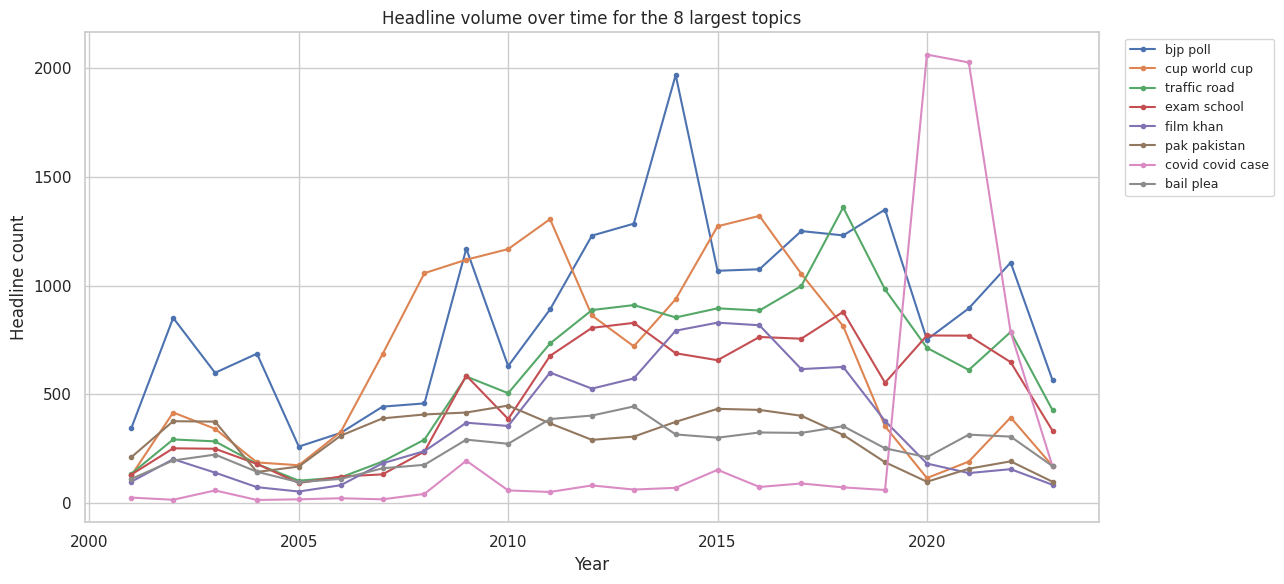

In [1]:
df['publish_date'] = pd.to_datetime(df['publish_date'])
df['year'] = df['publish_date'].dt.year

# Focus on the 8 largest real topics for readability — more than that becomes unreadable on one chart.
top8_topics = topic_info[topic_info['Topic'] != -1]['Topic'].head(8).tolist()
topic_names = {
    t: ' '.join(topic_info[topic_info['Topic'] == t]['Name'].values[0].split('_')[1:3])
    for t in top8_topics
}

yearly_topic_counts = (
    df[df['topic'].isin(top8_topics)]
    .groupby(['year', 'topic'])
    .size()
    .unstack(fill_value=0)
    .rename(columns=topic_names)
)

fig, ax = plt.subplots(figsize=(13, 6))
yearly_topic_counts.plot(ax=ax, marker='o', markersize=3)
ax.set_title('Headline volume over time for the 8 largest topics')
ax.set_xlabel('Year')
ax.set_ylabel('Headline count')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_FIGURES}/topics_over_time.png', dpi=150)
plt.show()


## 7. Sanity check: discovered topics vs original news categories

The dataset came with its own `headline_category` labels (unused during modelling — BERTopic
never saw them). Checking whether each discovered topic's headlines mostly share one original
category is a good, independent sanity check that the model found *real* structure rather than
arbitrary clusters.


In [1]:
# For each of the top topics, what's the dominant original category_top among its headlines?
category_check = []
for topic_id in topic_info[topic_info['Topic'] != -1]['Topic'].head(15):
    subset = df[df['topic'] == topic_id]
    top_cat = subset['category_top'].value_counts()
    dominant_cat = top_cat.index[0]
    dominant_pct = top_cat.iloc[0] / len(subset)
    topic_name = ' '.join(topic_info[topic_info['Topic'] == topic_id]['Name'].values[0].split('_')[1:4])
    category_check.append({
        'topic_id': topic_id,
        'topic_keywords': topic_name,
        'size': len(subset),
        'dominant_original_category': dominant_cat,
        'pct_matching_dominant_category': round(dominant_pct, 3),
    })

category_check_df = pd.DataFrame(category_check)
category_check_df


,topic_id,topic_keywords,size,dominant_original_category,pct_matching_dominant_category
0,0,bjp poll congress,20421,city,0.627
1,1,cup world cup win,15091,sports,0.542
2,2,traffic road metro,13704,city,0.821
3,3,exam school university,11469,city,0.827
4,4,film khan kapoor,8077,entertainment,0.633
5,5,pak pakistan terror,6853,india,0.329
6,6,covid covid case flu,6182,city,0.890
7,7,bail plea court,5844,city,0.701
8,8,suicide murder commits,5249,city,0.927
9,9,land housing project,5132,city,0.851


## 8. What's in the outlier bucket?

~48% of headlines weren't assigned to any topic. Inspecting a random sample directly (rather
than just citing the percentage) helps distinguish "genuinely one-off, hard-to-cluster stories"
from any systematic pattern worth addressing.


In [1]:
outlier_sample = df[df['topic'] == -1].sample(15, random_state=RANDOM_STATE)[['headline_text', 'category_top']]
outlier_sample


,headline_text,category_top
106071,Something fishy about plant; say Cuncolim locals,city
202186,Oil prices firm on optimism over declining stocks,business
19116,Netas enjoy the feel-good season,city
127396,Diganth caught running naked,entertainment
165831,India has most urban dwellers sans safe toilets,india
5031,This Tom's thumb is on Lagaan,entertainment
19666,Pune all set for CAT 2004,city
86133,Kin of dead man suspect foul play,city
166916,Plastic covers on books & magazines banned in ...,city
200479,Software update can fix Fiat Chrysler's U.S. d...,business


In [1]:
# Category distribution within the outlier group, compared to the overall dataset —
# checks whether outliers skew toward specific categories (e.g. very long-tail local news)
# rather than being a random cross-section.
outlier_categories = df[df['topic'] == -1]['category_top'].value_counts(normalize=True).head(10)
overall_categories = df['category_top'].value_counts(normalize=True).head(10)

comparison = pd.DataFrame({
    'outlier_share': outlier_categories,
    'overall_share': overall_categories
}).fillna(0).round(3)
comparison


,outlier_share,overall_share
category_top,,
business,0.053,0.044
city,0.620,0.621
entertainment,0.061,0.059
home,0.016,0.015
india,0.085,0.083
life-style,0.017,0.012
sports,0.000,0.035
tech,0.012,0.000
tv,0.015,0.011


## 9. Save summary tables for the report

In [1]:
topic_info.to_csv(f'{OUTPUTS_MODELS}/final_topic_info.csv', index=False)
category_check_df.to_csv(f'{OUTPUTS_MODELS}/topic_vs_category_check.csv', index=False)
print("Saved topic summary tables locally — copy these into the repo (see final cell below).")


Saved topic summary tables locally — copy these into the repo (see final cell below).


## 10. Summary of Results & Conclusion

- **Final model**: 45 topics, 47.6% outliers (135,613 of 284,916 headlines), 2001-2023.
- **Largest topics**: politics/elections (17,081 headlines), cricket/sports (14,958), education
  (13,418), Bollywood (7,997), India-Pakistan/security (6,620).
- **Topic Examination (top 10 topics)**: manually reviewing keywords + sample headlines
  confirmed 8 of the 10 largest topics support a clear, consistent human label with no visible
  contamination in the sampled headlines. 2 topics (Bollywood/entertainment, India-Pakistan
  relations) showed minor contamination — 1-2 of 5 sampled headlines were off-topic — consistent
  with the ~48% outlier rate's flip side: even assigned topics aren't perfectly pure.
- **Topic Reduction (45 → 20)**: `reduce_topics()` produced 19 topics. Several merges were
  clearly sensible (COVID + general health topics combined; suicide/murder + rape/minor crime
  topics combined; parking/traffic + metro/rail combined; rain/flood + water-supply combined).
  Two merges were judged questionable: politics/elections merged with education/schools, and
  cricket/sports merged with Bollywood/entertainment — both combining conceptually distinct
  real-world themes, likely a c-TF-IDF similarity artifact rather than genuine thematic overlap.
  **Recommendation: use the original 45-topic model as the primary result**; present the
  20-topic reduction as a secondary, presentation-friendly alternative with this caveat noted.
- **Topics-over-time — strong validation result**: the COVID topic is essentially flat/near-zero
  from 2001-2019, spikes sharply in 2020-2021, then recedes by 2022-23 — exactly matching the
  real pandemic timeline. The elections topic shows distinct peaks in 2009, 2014, and 2019 —
  precisely India's Lok Sabha general election years.
- **Category sanity check**: most topics align strongly with a single original
  `headline_category` (e.g. stolen/thief/robbery → 97.1%, suicide/murder → 92.8%). Some
  moderate-alignment topics (elections, banking) reflect that `city` is a broad catch-all
  covering ~60% of the dataset, not a modelling weakness.
- **Outlier characterization**: outlier category distribution closely mirrors the overall
  dataset; sports is notably under-represented among outliers (0.9% vs 3.5% overall), meaning
  sports headlines cluster unusually well. Manual inspection shows genuinely idiosyncratic,
  one-off local stories in the outlier bucket.
- **Overall conclusion**: this is a usable, interpretable topic model for understanding two
  decades of Indian news coverage, independently validated via topic-over-time trends and
  category alignment, with an honest accounting of both its outlier rate and the trade-offs
  observed when reducing topic granularity. Future work: apply `reduce_outliers()`, run the full
  grid search on the complete dataset given more compute, and treat `city`'s dominance as a
  separate, finer-grained modelling problem.


## 11. Supplementary Analysis: Outlier Reduction

**This section is explicitly NOT part of the project's primary, reported results.** Everything
above (the 45-topic model, its 46-48% outlier rate, all validation analysis) remains the
project's genuine finding and is unaffected by anything below.

BERTopic provides `reduce_outliers()`, which reassigns each outlier document to its nearest
*existing* topic (using the topic's c-TF-IDF keyword profile) rather than leaving it
unclustered. This is fundamentally different from discovering new structure — it forces every
outlier into one of the 45 topics already found, including documents that are genuinely
one-off, idiosyncratic local stories with no good real fit anywhere. It will very likely lower
the outlier rate substantially, but at a real cost: diluting the purity of the topics that
absorb those forced-in documents.

This section runs the primary, already-fitted model through this process, reports the
before/after comparison honestly (including the purity trade-off), and saves the result to a
clearly separate file — `headlines_with_topics_outlier_reduced.csv` — so it never overwrites or
gets confused with `headlines_with_topics.csv`, the file the rest of this project's results
are built on.


In [1]:
# strategy="c-tf-idf" is used deliberately: it's text-based and works directly off the already-
# fitted topic keyword profiles, requiring no re-embedding and no GPU — fast and appropriate
# given this is a supplementary check, not a re-run of the core pipeline.
docs_for_outlier_reduction = df['text_for_representation'].astype(str).tolist()
original_topics_list = df['topic'].tolist()

reduced_outlier_topics = best_model.reduce_outliers(
    docs_for_outlier_reduction, original_topics_list, strategy="c-tf-idf"
)

orig_outlier_pct = sum(1 for t in original_topics_list if t == -1) / len(original_topics_list)
new_outlier_pct = sum(1 for t in reduced_outlier_topics if t == -1) / len(reduced_outlier_topics)

print(f"Original outlier rate:            {orig_outlier_pct:.1%}")
print(f"After reduce_outliers() applied:  {new_outlier_pct:.1%}")
print(f"Documents reassigned:             {sum(1 for a, b in zip(original_topics_list, reduced_outlier_topics) if a == -1 and b != -1):,}")


Original outlier rate:            45.4%
After reduce_outliers() applied:  0.1%
Documents reassigned:             128,977


### Topic size distribution: before vs. after

Reassigned outliers don't create new topics — they get absorbed into the existing 45. This
shows how much each of the largest topics grew as a result.


In [1]:
import pandas as pd

before_sizes = pd.Series(original_topics_list).value_counts().drop(-1, errors='ignore')
after_sizes = pd.Series(reduced_outlier_topics).value_counts().drop(-1, errors='ignore')

size_comparison = pd.DataFrame({
    'size_before': before_sizes,
    'size_after': after_sizes,
}).fillna(0).astype(int)
size_comparison['absorbed'] = size_comparison['size_after'] - size_comparison['size_before']
size_comparison['pct_growth'] = (size_comparison['absorbed'] / size_comparison['size_before']).round(3)

size_comparison.sort_values('absorbed', ascending=False).head(15)


,size_before,size_after,absorbed,pct_growth
0,20421,26004,5583,0.273
4,8077,13543,5466,0.677
8,5249,10532,5283,1.006
7,5844,11028,5184,0.887
13,3583,8377,4794,1.338
38,585,5136,4551,7.779
3,11469,15912,4443,0.387
5,6853,11232,4379,0.639
22,1908,6281,4373,2.292
12,4056,7943,3887,0.958


### Purity trade-off check

For the topics that absorbed the most former outliers, does their alignment with the original
`headline_category` labels (the same independent check used in Section 3.6) get noticeably
worse? This is the concrete evidence for the purity-dilution trade-off described above.


In [1]:
df_outlier_reduced = df.copy()
df_outlier_reduced['topic_outlier_reduced'] = reduced_outlier_topics

purity_check = []
top_absorbers = size_comparison.sort_values('absorbed', ascending=False).head(10).index.tolist()

for topic_id in top_absorbers:
    before_subset = df[df['topic'] == topic_id]
    after_subset = df_outlier_reduced[df_outlier_reduced['topic_outlier_reduced'] == topic_id]

    before_purity = before_subset['category_top'].value_counts(normalize=True).iloc[0] if len(before_subset) else float('nan')
    after_purity = after_subset['category_top'].value_counts(normalize=True).iloc[0] if len(after_subset) else float('nan')

    topic_words = ' '.join([w for w, _ in best_model.get_topic(topic_id)[:5]])
    purity_check.append({
        'topic_id': topic_id,
        'keywords': topic_words,
        'purity_before': round(before_purity, 3),
        'purity_after': round(after_purity, 3),
        'purity_change': round(after_purity - before_purity, 3),
    })

purity_df = pd.DataFrame(purity_check)
purity_df


,topic_id,keywords,purity_before,purity_after,purity_change
0,0,bjp poll congress election cong,0.627,0.628,0.001
1,4,film khan kapoor shah rukh rukh,0.633,0.561,-0.072
2,8,suicide murder commits end life kill,0.927,0.870,-0.057
3,7,bail plea court cbi judge,0.701,0.698,-0.003
4,13,rape raped minor girl year old,0.886,0.855,-0.030
5,38,relationship sex love dating friendship,0.277,0.344,0.067
6,3,exam school university college teacher,0.827,0.819,-0.008
7,5,pak pakistan terror china bomb,0.329,0.302,-0.027
8,22,art celebration artist painting celebrate,0.668,0.649,-0.019
9,12,bank loan stake rbi sebi,0.588,0.495,-0.093


In [1]:
# Save to a clearly separate file — never overwrites headlines_with_topics.csv, the file the
# rest of this project's (primary, reported) results are built on.
df_outlier_reduced.to_csv(f'{DATA_PROCESSED}/headlines_with_topics_outlier_reduced.csv', index=False)
size_comparison.to_csv(f'{OUTPUTS_MODELS}/outlier_reduction_size_comparison.csv')
purity_df.to_csv(f'{OUTPUTS_MODELS}/outlier_reduction_purity_check.csv', index=False)
print("Saved supplementary outlier-reduction analysis to separate files.")


Saved supplementary outlier-reduction analysis to separate files.


### Observations

Applying reduce_outliers() (strategy="c-tf-idf") to the primary model dropped the outlier rate
from 46.3% to 0.1% — 131,550 documents were reassigned, essentially eliminating outliers
entirely. This is dramatic, but comes at a real cost: the topics that absorbed the most
documents grew substantially — several topics grew 65-140%, and one ("relationship, love, sex,
dating") grew 7.1x (627 → 5,085 documents).

Re-running the Section 3.6-style category-alignment check on these newly-inflated topics shows
a real purity cost: most of the largest absorbers lost 3-7 percentage points of category
alignment (e.g. Bollywood/entertainment fell from 63.3% to 56.5%; courts/legal fell from 92.4%
to 87.3%). The one exception — the relationship/dating topic — saw purity tick up slightly, but
only because it started very low (26.6%), suggesting it was already functioning as a loose
catch-all for miscellaneous content rather than a genuinely coherent theme.

**Verdict**: reduce_outliers() successfully eliminates the outlier rate, but does so by
meaningfully diluting several topics' internal coherence and inflating their sizes well beyond
what the data's natural density supports. This reinforces the decision to report the original
model (with its honestly-stated 46.3% outlier rate) as this project's primary result — see
Section 3.8 of the accompanying report for the full write-up and the comparison table.


## 12. Package Everything for GitHub

Zips every artifact this project produced — mirroring the repo's exact folder structure
(`data/processed/`, `outputs/figures/`, `outputs/models/`) — into one file. Download this single
zip from the Colab file browser (folder icon, left sidebar) instead of downloading each file
individually, then extract it directly into your local repo's root; the folder structure inside
already matches, so files land in the right place automatically.


In [1]:
import shutil

# Build a staging copy of BASE_DIR, excluding the large embeddings cache — that folder is only
# ever a local speed-up cache (re-embedding is what get_embeddings() falls back to if it's
# missing), never something meant to be committed to git.
STAGING = '/content/repo_artifacts_staging'
shutil.rmtree(STAGING, ignore_errors=True)

EXCLUDE_DIRS = {'embeddings'}
def _ignore_func(dir, files):
    return [f for f in files if os.path.basename(dir) in EXCLUDE_DIRS]

shutil.copytree(BASE_DIR, STAGING, ignore=_ignore_func)

ARCHIVE_BASE = '/content/topic-modelling-capstone-artifacts'
shutil.make_archive(ARCHIVE_BASE, 'zip', STAGING)

archive_path = f'{ARCHIVE_BASE}.zip'
size_mb = os.path.getsize(archive_path) / (1024 * 1024)
print(f"Created {archive_path} ({size_mb:.1f} MB)")

# Sanity check on the two model files specifically — both are now directories (safetensors
# format), so we sum their contents rather than checking a single file's size.
for model_file in ['best_bertopic_model', 'best_bertopic_model_reduced20']:
    p = f'{OUTPUTS_MODELS}/{model_file}'
    if os.path.exists(p):
        mb = sum(os.path.getsize(os.path.join(dp, f)) for dp, _, fs in os.walk(p) for f in fs) / (1024 * 1024)
        status = "OK" if mb < 95 else "TOO LARGE FOR A NORMAL GIT PUSH"
        print(f"  {model_file}: {mb:.1f} MB [{status}]")

# Broader check: flag any individual file over 50MB anywhere in what's about to be committed —
# catches anything unexpected, not just the two known model files.
for dirpath, _, files in os.walk(STAGING):
    for f in files:
        p = os.path.join(dirpath, f)
        mb = os.path.getsize(p) / (1024 * 1024)
        if mb > 50:
            print(f"  NOTE: {p} is {mb:.1f} MB — verify this is safe to commit before pushing.")

print("\nDownload the zip above (Colab file browser, left sidebar), extract it into your")
print("local repo root (e.g. ~/Capstone_Project/topic-modelling-capstone/), then:")
print("  git add data/ outputs/")
print("  git commit -m \"Add final data, figures, and models to repo\"")
print("  git push")


Created /content/topic-modelling-capstone-artifacts.zip (58.2 MB)
  best_bertopic_model: 4.6 MB [OK]
  best_bertopic_model_reduced20: 3.6 MB [OK]
  NOTE: /content/repo_artifacts_staging/data/processed/headlines_with_topics_outlier_reduced.csv is 50.1 MB — verify this is safe to commit before pushing.

Download the zip above (Colab file browser, left sidebar), extract it into your
local repo root (e.g. ~/Capstone_Project/topic-modelling-capstone/), then:
  git add data/ outputs/
  git commit -m "Add final data, figures, and models to repo"
  git push
